In [26]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from scipy.stats import levene, shapiro, ttest_1samp, ttest_ind
from statistics import stdev 

Reading data from file and displaying first 5 rows

In [2]:
data = pd.read_csv("data.csv",index_col = 0)

In [3]:
data.head()

,Old Scheme (in thousands),New Scheme (in thousands)
SALESPERSON,,
1,57,62
2,103,122
3,59,54
4,75,82
5,84,84


Question # 1 - Find the mean of old scheme and new scheme column

In [4]:
data.describe().loc['mean']

Old Scheme (in thousands)    68.033333
New Scheme (in thousands)    72.033333
Name: mean, dtype: float64

In [5]:
data.mean()

Old Scheme (in thousands)    68.033333
New Scheme (in thousands)    72.033333
dtype: float64

Question # 2 - Use the five percent significance test over the data to determine the p value to 
check new scheme has significantly raised outputs?

Following steps needs to be performed to get the result.

1 - Check the normality of data 
2 - Establish Null and Alternate hypothesis
3 - Find the method to be used and find p value
4 - Reject or fail to reject the null hypothesis depending upon p value



Check for Normality
1. Check if mean and median are almost same 
2. Plot the data and verify it
Normality can also be checked with Saphiro test

In [20]:
print(data['Old Scheme (in thousands)'].median())
print(data['New Scheme (in thousands)'].median())

67.0
74.0


For old scheme - mean 68 and median 67, almost equal.
For new scheme - mean 72 and median 74, almost equal.
And n = 30 is large enough 
So we can assume that distribution is normal for both old and new scheme.Lets plot it and check as well. 

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


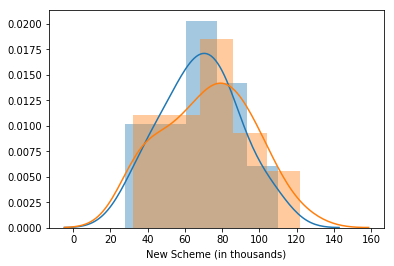

In [8]:
sns.distplot(data['Old Scheme (in thousands)'])
sns.distplot(data['New Scheme (in thousands)'])
# from the plot data looks normally distributed

In [11]:
# Shapiro Test of old scheme
# Null Hypothesis - Data is normally distributed
# Alternate Hypothesis - Data is not normally distributed

shapiro(data['Old Scheme (in thousands)'])

#p-value is greater than 0.05 so data is normally distributed

(0.9885101914405823, 0.9813658595085144)

In [12]:
# Shapiro Test of new scheme
# Null Hypothesis - Data is normally distributed
# Alternate Hypothesis - Data is not normally distributed

shapiro(data['New Scheme (in thousands)'])
#p-value is greater than 0.05 so data is normally distributed

(0.9687567353248596, 0.5057420134544373)

In [16]:
# Levene's Test

# H0: All variances are equal
# Ha: Atleast one of the variances not equal
levene(data['Old Scheme (in thousands)'],data['New Scheme (in thousands)'])
# p-value > 0.05 hence all variances are equal

LeveneResult(statistic=1.063061539437244, pvalue=0.30679836081811235)

In [42]:
# Null hypothesis Ho- μold - μnew = 0 (No significance difference between two schems or new scheme has not raised the output significantly)
# Alternate hypothesis Ha - μold - μnew < 0 (New schem output is more than old scheme output)

#Since the population standard deviation is unkown t test will be used. It will be right tailed t test
#Since the data is collected from same population paired t test will be used. 


stats.ttest_rel(data['Old Scheme (in thousands)'], data['New Scheme (in thousands)'])



Ttest_relResult(statistic=-1.5559143823544377, pvalue=0.13057553961337662)

In [43]:
p=1-stats.t.cdf(1.5559,30)
print(p)
#Since p value is greater than 0.05, there is no sufficient evidence to reject null hypothesis

0.06510979171859932


In [31]:
#We can also use the below ttest_1samp formula too. It gives the same result

ttest_1samp(data['Old Scheme (in thousands)']- data['New Scheme (in thousands)'], 0)



Ttest_1sampResult(statistic=-1.5559143823544377, pvalue=0.13057553961337662)

In [45]:
p=1-stats.t.cdf(1.5559,30)
print(p)
#Since p value is greater than 0.05, there is no sufficient evidence to reject null hypothesis

0.06510979171859932


Question # 3 - What conclusion does the test (p-value) lead to? 

In [ ]:
#Since p value is greater than 0.05, there is no sufficient evidence to reject null haypothesis. 
#So new scheme has not significantly increased the output

QUestion # 4 - Suppose it has been calculated that in order for Titan to break even, the average output must increase by £5000 in the scheme compared to the old scheme. If this figure is alternative hypothesis, what is:
        a) The probability of a type 1 error? (2.5 points)

        b) What is the p- value of the hypothesis test if we test for a difference of $5000? (5 points)

        c) Power of the test (5 points)

In [ ]:
#4(a) - Probability of type 1 error = level of significance (rejecting null hypothesis when it is true)
#Since level of significance is 0.05, probability of type 1 error is 5%.

In [34]:
data['diff']  = data['New Scheme (in thousands)'] - data['Old Scheme (in thousands)']

In [35]:
data.head()

,Old Scheme (in thousands),New Scheme (in thousands),diff
SALESPERSON,,,
1,57,62,5
2,103,122,19
3,59,54,-5
4,75,82,7
5,84,84,0


In [38]:
#onesample_results = stats.ttest_1samp(df['diff'], 5)
#print(onesample_results)

ttest_1samp(data['diff'],5)

Ttest_1sampResult(statistic=-0.3889785955886094, pvalue=0.7001334912613286)

In [39]:
print(stats.t.ppf(1-0.005, 58))

2.6632869538098674


In [40]:
#p value for single tailed test
p=1-stats.t.cdf(0.388978,30)
print(p)

0.35001984398317565


In [46]:
meanDiff = data['diff'].mean()
meanStd = data['diff'].std()
s = meanDiff/meanStd

In [52]:
import statsmodels.stats.power as por
totaln = 30
alpha = 0.05
degfre=58

por.ttest_power(s, totaln, alpha, alternative='larger')

0.4501248712978272